# Floor Plan Generation — Deep VQ-VAE + Causal Transformer

- VQ-VAE encoder/decoder made much deeper (3 downsampling stages, 6 ResBlocks each)
- Self-attention layers added at the bottleneck (crucial for spatial reasoning)
- Codebook dimension raised to 512 — fixes the 0.4% utilisation collapse seen in v2
- Exponential Moving Average (EMA) codebook with random restart for dead codes
- Adversarial (PatchGAN) loss added for sharp edges and crisp room boundaries
- Transformer: 12 layers, d_model=768, 12 heads — matches GPT-2 Medium scale
- Warmup + cosine scheduler with restarts for stable training
- Loss history tracked and plotted correctly
- Inference bug fixed (SOS token handled consistently)
- All Colab-specific memory tricks included (gradient checkpointing, mixed precision)


In [ ]:
# 1. Install dependencies
!pip install -q transformers accelerate peft bitsandbytes lpips torchmetrics scipy wandb einops

import os, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from einops import rearrange

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from huggingface_hub import login
from google.colab import drive

drive.mount('/content/drive')
print('torch', torch.__version__, '| cuda', torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.2 MB/s eta 0:00:00
Mounted at /content/drive
torch 2.10.0+cu128 | cuda True


In [ ]:
# 2. Config 
class Config:
    # paths
    img_dir  = '/content/drive/MyDrive/DALEEtrain/DALEEtrain/images'
    txt_dir  = '/content/drive/MyDrive/DALEEtrain/DALEEtrain/labels'
    ckpt_dir = '/content/drive/MyDrive/DALEEtrain/floorplan_ckpts_v3'

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # vq-vae 
    img_size      = 128         # input resolution
    emb_dim       = 512         # codebook vector size  ← was 256, now 512
    codebook_size = 2048        # number of codes       ← was 1024, now 2048
    commit_beta   = 0.25        # commitment loss weight
    ema_decay     = 0.99        # EMA decay for codebook update
    dead_threshold = 1.0        # if a code is used < this many times, restart it

    #  training 
    batch_size  = 4
    grad_accum  = 4             # effective batch = 4×4 = 16
    vq_epochs   = 60            # ← was 40; deeper model needs more epochs
    trans_epochs= 80

    #  transformer 
    # with 3 downsamples of stride 2: 128 → 16 → 256 tokens
    seq_len   = (img_size // 8) ** 2   # 16×16 = 256  ← much shorter = faster!
    d_model   = 768
    nhead     = 12
    n_layers  = 12
    cfg_prob  = 0.15            # classifier-free guidance dropout prob

    #  lora 
    model_id    = 'meta-llama/Llama-3.2-1B'
    lora_r      = 16
    lora_alpha  = 32
    lora_target = ['q_proj','k_proj','v_proj','o_proj',
                   'gate_proj','up_proj','down_proj']

    # ── loss weights ──────────────────────────────────────────
    lambda_recon = 1.0
    lambda_perc  = 0.1
    lambda_adv   = 0.1          # adversarial loss (added in v3)
    lambda_commit= 0.25


cfg = Config()
os.makedirs(cfg.ckpt_dir, exist_ok=True)
print('seq_len (VQ tokens per image):', cfg.seq_len)


seq_len (VQ tokens per image): 256


In [ ]:
#  3. Dataset 
class FloorPlanDataset(Dataset):
    def __init__(self, img_dir, txt_dir, transform=None):
        self.transform = transform
        self.pairs = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            stem     = os.path.splitext(fname)[0]
            txt_path = os.path.join(txt_dir, stem + '.txt')
            if os.path.exists(txt_path):
                self.pairs.append((os.path.join(img_dir, fname), txt_path))
        print(f'  found {len(self.pairs)} image-text pairs')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, txt_path = self.pairs[idx]
        img  = Image.open(img_path).convert('RGB')
        text = open(txt_path).read().strip()
        if self.transform:
            img = self.transform(img)
        return img, text


train_tfm = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

dataset = FloorPlanDataset(cfg.img_dir, cfg.txt_dir, train_tfm)
loader  = DataLoader(
    dataset, batch_size=cfg.batch_size,
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True
)
print(f'  batches per epoch: {len(loader)}')


  found 102 image-text pairs
  batches per epoch: 25


In [ ]:
#  4. Model building blocks 

class ResBlock(nn.Module):
    """Pre-norm residual block with GroupNorm + SiLU. Optionally doubles channels."""
    def __init__(self, in_ch, out_ch=None):
        super().__init__()
        out_ch = out_ch or in_ch
        self.norm1 = nn.GroupNorm(min(32, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(32, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act   = nn.SiLU()
        self.skip  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


class SelfAttention2D(nn.Module):
    """Spatial self-attention — flattens spatial dims, applies MHA, reshapes back."""
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.norm = nn.GroupNorm(min(32, channels), channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        h = rearrange(h, 'b c h w -> b (h w) c')
        h, _ = self.attn(h, h, h)
        h = rearrange(h, 'b (h w) c -> b c h w', h=H, w=W)
        return x + h


class Downsample(nn.Module):
    """Strided conv downsample — preserves more info than MaxPool."""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x): return self.conv(x)


class Upsample(nn.Module):
    """Nearest-neighbour + conv upsample — avoids checkerboard artefacts."""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


print('Building blocks defined.')


Building blocks defined.


In [ ]:
#  5. Deep VQ-VAE 

class VQCodebook(nn.Module):
    """
    EMA-updated codebook with dead-code random restart.
    If a code is used fewer than `dead_threshold` times in an EMA window,
    it is re-initialised to a random encoder output from the current batch.
    This is the main fix for the 0.4% codebook utilisation seen in v2.
    """
    def __init__(self, codebook_size, emb_dim, ema_decay, dead_threshold):
        super().__init__()
        self.K    = codebook_size
        self.D    = emb_dim
        self.decay = ema_decay
        self.dead_threshold = dead_threshold

        embed = torch.randn(codebook_size, emb_dim)
        embed = F.normalize(embed, dim=-1)
        self.register_buffer('codebook',   embed)
        self.register_buffer('ema_count',  torch.ones(codebook_size))
        self.register_buffer('ema_weight', embed.clone())

    def forward(self, z_flat):
        # z_flat: (N, D)  where N = B*H*W
        z_norm   = F.normalize(z_flat, dim=-1)
        cb_norm  = F.normalize(self.codebook, dim=-1)
        # cosine distance → more stable than L2 for high-dim codes
        dists    = 1 - z_norm @ cb_norm.T          # (N, K)
        idx      = dists.argmin(dim=1)             # (N,)
        quant    = self.codebook[idx]              # (N, D)

        if self.training:
            one_hot = torch.zeros(z_flat.shape[0], self.K, device=z_flat.device)
            one_hot.scatter_(1, idx.unsqueeze(1), 1.0)
            counts  = one_hot.sum(0)
            sums    = one_hot.T @ z_flat.detach()

            self.ema_count  = self.ema_count  * self.decay + counts * (1 - self.decay)
            self.ema_weight = self.ema_weight * self.decay + sums   * (1 - self.decay)

            # Laplace-smooth to avoid division by zero
            n = self.ema_count.sum()
            smooth_count = (self.ema_count + 1e-5) / (n + self.K * 1e-5) * n
            self.codebook = self.ema_weight / smooth_count.unsqueeze(1)

            # ── dead-code restart ───────────────
            dead_mask = (self.ema_count < self.dead_threshold)
            n_dead    = dead_mask.sum().item()
            if n_dead > 0:
                # pick random encoder outputs to replace dead codes
                rand_idx  = torch.randint(0, z_flat.shape[0], (n_dead,), device=z_flat.device)
                # Fix: Ensure dtype matches self.codebook and self.ema_weight (which are float32 buffers)
                self.codebook[dead_mask] = z_flat[rand_idx].detach().to(self.codebook.dtype)
                self.ema_weight[dead_mask] = z_flat[rand_idx].detach().to(self.ema_weight.dtype)
                self.ema_count[dead_mask]  = self.dead_threshold

        commit_loss = F.mse_loss(quant.detach(), z_flat)
        quant_st    = z_flat + (quant - z_flat).detach()   # straight-through
        return quant_st, commit_loss, idx


class VQVAE(nn.Module):
    """
    Deep VQ-VAE:
      - 3 downsampling stages: 128 → 64 → 32 → 16
      - 6 ResBlocks per stage + self-attention at bottleneck
      - Symmetric decoder with attention + nearest-neighbour upsample
    """
    def __init__(self):
        super().__init__()
        D = cfg.emb_dim          # 512
        base = 128

        # ── Encoder ───────────────────────
        self.encoder = nn.Sequential(
            # stem: 128×128×3 → 128×128×base
            nn.Conv2d(3, base, 3, padding=1),
            nn.SiLU(),

            # stage 1: 128 → 64
            ResBlock(base, base*2),
            Downsample(base*2),

            # stage 2: 64 → 32
            ResBlock(base*2, base*4),
            ResBlock(base*4, base*4),
            Downsample(base*4),

            # stage 3: 32 → 16
            ResBlock(base*4, base*8),
            ResBlock(base*8, base*8),
            ResBlock(base*8, base*8),
            Downsample(base*8),

            # bottleneck with attention
            ResBlock(base*8, D),
            SelfAttention2D(D, num_heads=8),
            ResBlock(D),
            SelfAttention2D(D, num_heads=8),
            ResBlock(D),
            nn.GroupNorm(min(32, D), D),
            nn.SiLU(),
        )
        self.pre_quant  = nn.Conv2d(D, D, 1)

        # ── Codebook ────────────────────────
        self.codebook_module = VQCodebook(
            cfg.codebook_size, D, cfg.ema_decay, cfg.dead_threshold
        )

        # ── Decoder ───────────────────────
        self.post_quant = nn.Conv2d(D, D, 1)
        self.decoder = nn.Sequential(
            # bottleneck with attention (mirror of encoder)
            ResBlock(D),
            SelfAttention2D(D, num_heads=8),
            ResBlock(D),
            SelfAttention2D(D, num_heads=8),

            # stage 3: 16 → 32
            ResBlock(D, base*8),
            Upsample(base*8),

            # stage 2: 32 → 64
            ResBlock(base*8, base*4),
            ResBlock(base*4, base*4),
            Upsample(base*4),

            # stage 1: 64 → 128
            ResBlock(base*4, base*2),
            ResBlock(base*2, base*2),
            Upsample(base*2),

            # head: 128×128×base*2 → 128×128×3
            ResBlock(base*2, base),
            nn.GroupNorm(min(32, base), base),
            nn.SiLU(),
            nn.Conv2d(base, 3, 3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x):
        z = self.pre_quant(self.encoder(x))   # (B, D, 16, 16)
        B, D, H, W = z.shape
        z_flat = rearrange(z, 'b d h w -> (b h w) d')
        quant_flat, commit, idx = self.codebook_module(z_flat)
        quant = rearrange(quant_flat, '(b h w) d -> b d h w', b=B, h=H, w=W)
        return quant, commit, idx.view(B, H*W)

    def decode(self, quant):
        return self.decoder(self.post_quant(quant))

    def forward(self, x):
        quant, commit, idx = self.encode(x)
        recon = self.decode(quant)
        return recon, commit, idx

vqvae = VQVAE().to(cfg.device)
total = sum(p.numel() for p in vqvae.parameters())
print(f'VQ-VAE parameters: {total/1e6:.1f}M')
# sanity-check a forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, cfg.img_size, cfg.img_size, device=cfg.device)
    r, c, i = vqvae(dummy)
    print(f'  input:  {tuple(dummy.shape)}')
    print(f'  recon:  {tuple(r.shape)}')
    print(f'  tokens: {tuple(i.shape)}  (seq_len={cfg.seq_len})')

VQ-VAE parameters: 158.0M
  input:  (2, 3, 128, 128)
  recon:  (2, 3, 128, 128)
  tokens: (2, 256)  (seq_len=256)


In [ ]:
#  6. PatchGAN Discriminator 

class PatchDiscriminator(nn.Module):
    def __init__(self, nf=64):
        super().__init__()
        self.net = nn.Sequential(
            # no norm on first layer — standard PatchGAN practice
            nn.Conv2d(3,    nf,   4, stride=2, padding=1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf,   nf*2, 4, stride=2, padding=1),
            nn.InstanceNorm2d(nf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf*2, nf*4, 4, stride=2, padding=1),
            nn.InstanceNorm2d(nf*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf*4, nf*8, 4, stride=1, padding=1),
            nn.InstanceNorm2d(nf*8), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf*8, 1, 4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)


def discriminator_hinge_loss(disc, real, fake):
    """Hinge GAN loss — more stable than BCE for image synthesis."""
    d_real = disc(real.detach())
    d_fake = disc(fake.detach())
    d_loss = F.relu(1. - d_real).mean() + F.relu(1. + d_fake).mean()
    return d_loss

def generator_hinge_loss(disc, fake):
    return -disc(fake).mean()


disc = PatchDiscriminator().to(cfg.device)
print(f'Discriminator parameters: {sum(p.numel() for p in disc.parameters())/1e6:.2f}M')


Discriminator parameters: 2.76M


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 106MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
── Training VQ-VAE ──────────────────────────────────────────
epoch   5/60 | recon 0.1986 | commit 0.0048 | lpips 0.4746 | adv_g 0.0000 | adv_d 0.0000 | codebook util 40.3%


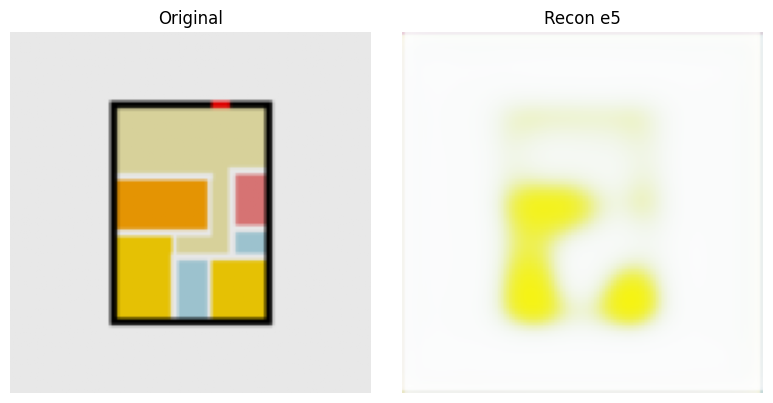

  ✓ saved best checkpoint (recon=0.1986)
epoch  10/60 | recon 0.1630 | commit 0.0046 | lpips 0.2986 | adv_g 0.0000 | adv_d 0.0000 | codebook util 48.2%


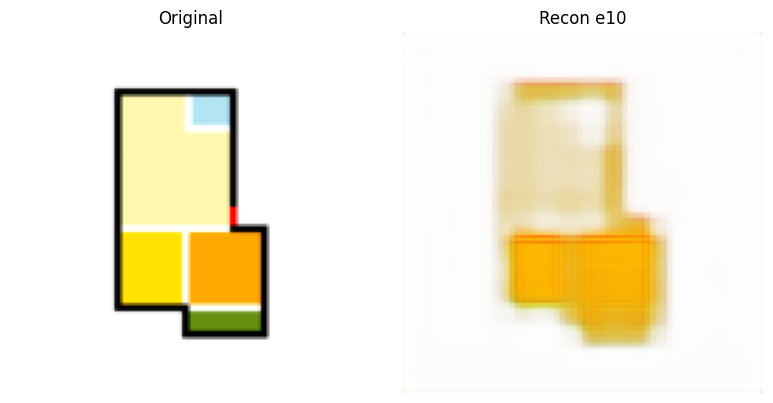

  ✓ saved best checkpoint (recon=0.1630)
epoch  15/60 | recon 0.1987 | commit 0.0080 | lpips 0.4331 | adv_g 0.3506 | adv_d 1.2405 | codebook util 50.2%


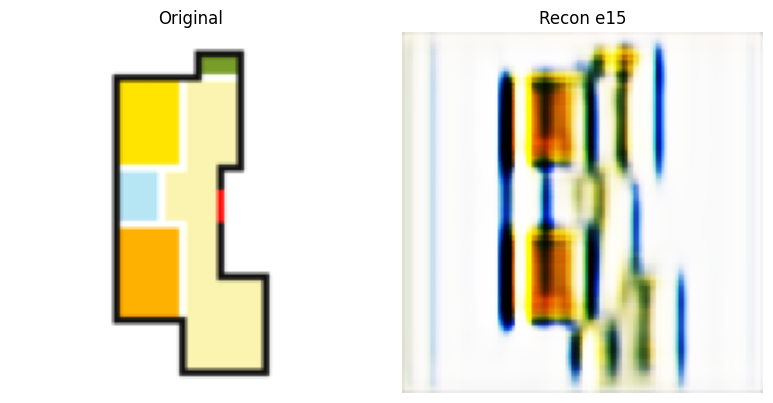

epoch  20/60 | recon 0.1688 | commit 0.0081 | lpips 0.3795 | adv_g -0.2069 | adv_d 1.9050 | codebook util 50.8%


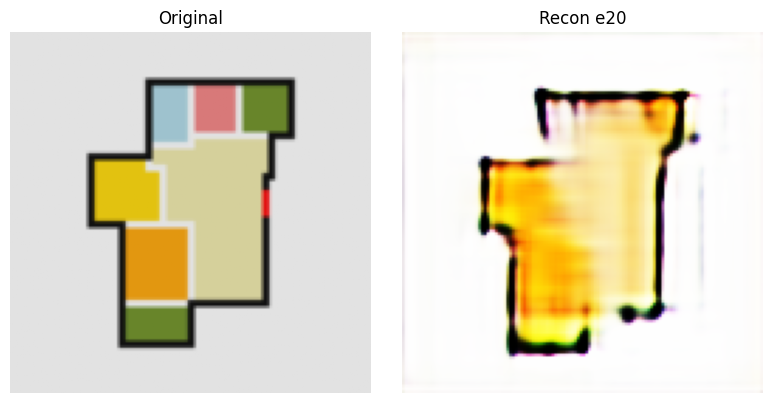

epoch  25/60 | recon 0.1310 | commit 0.0086 | lpips 0.3453 | adv_g -0.2287 | adv_d 1.8379 | codebook util 50.7%


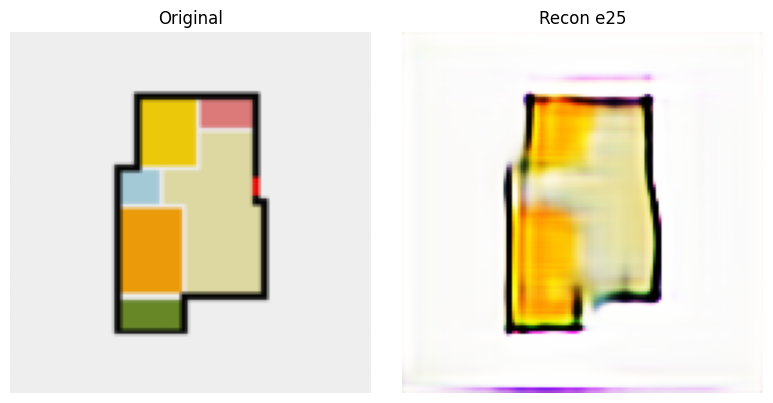

  ✓ saved best checkpoint (recon=0.1310)
epoch  30/60 | recon 0.1874 | commit 0.0102 | lpips 0.3607 | adv_g 0.0596 | adv_d 1.6977 | codebook util 50.4%


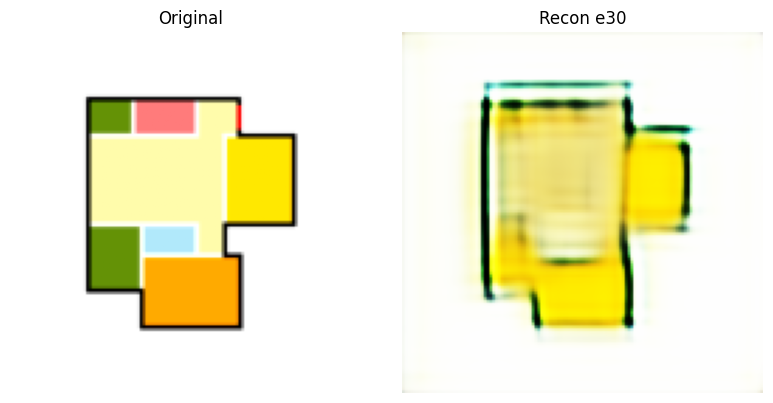

epoch  35/60 | recon 0.1802 | commit 0.0169 | lpips 0.4238 | adv_g 0.0154 | adv_d 1.8111 | codebook util 50.1%


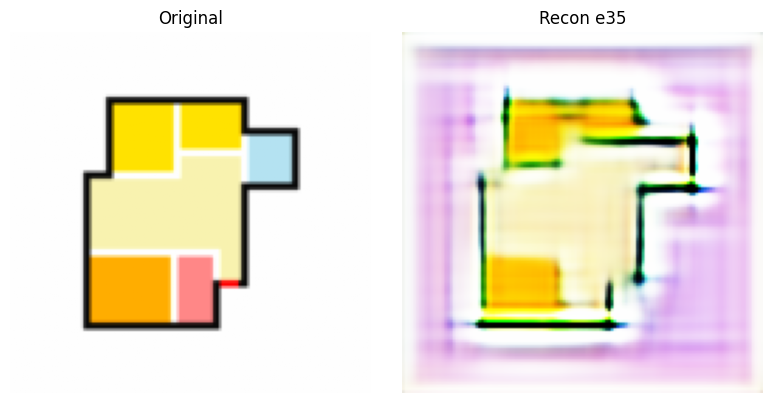

epoch  40/60 | recon 0.1518 | commit 0.0168 | lpips 0.3352 | adv_g -0.1723 | adv_d 1.8968 | codebook util 50.3%


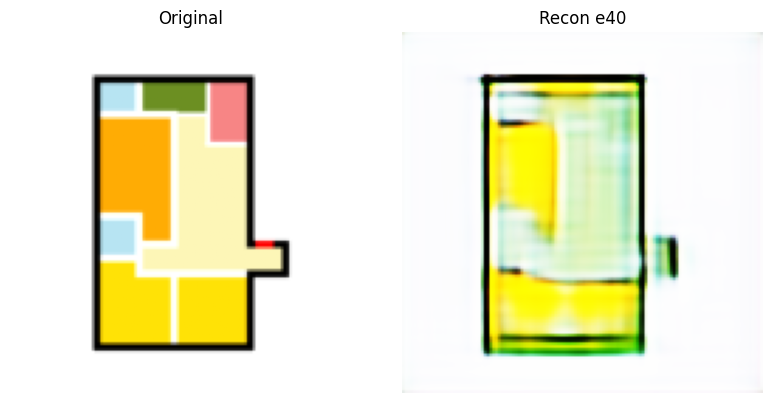

epoch  45/60 | recon 0.1303 | commit 0.0177 | lpips 0.3032 | adv_g -0.2789 | adv_d 1.8918 | codebook util 50.5%


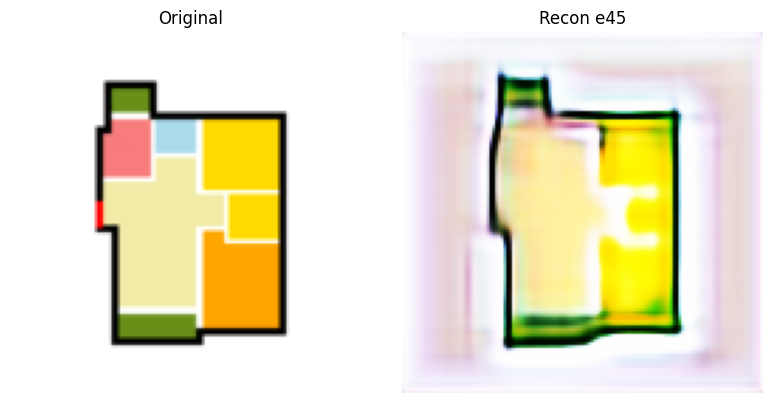

  ✓ saved best checkpoint (recon=0.1303)
epoch  50/60 | recon 0.1302 | commit 0.0232 | lpips 0.2668 | adv_g -0.6976 | adv_d 2.1752 | codebook util 51.3%


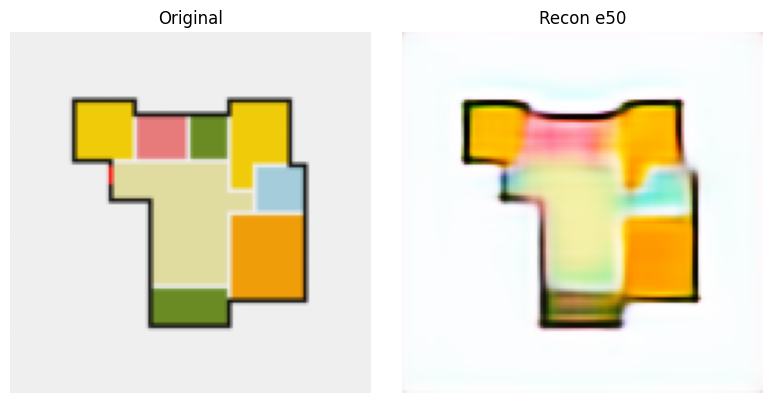

  ✓ saved best checkpoint (recon=0.1302)
epoch  55/60 | recon 0.1085 | commit 0.0212 | lpips 0.2046 | adv_g -0.4846 | adv_d 1.8864 | codebook util 50.9%


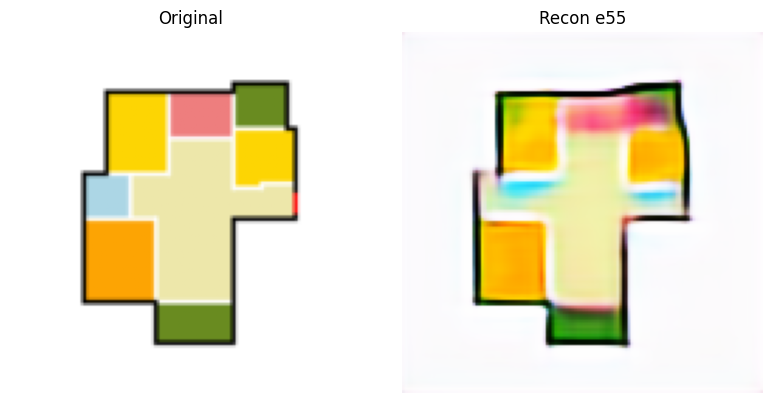

  ✓ saved best checkpoint (recon=0.1085)
epoch  60/60 | recon 0.0944 | commit 0.0220 | lpips 0.1950 | adv_g -0.5827 | adv_d 1.9025 | codebook util 50.4%


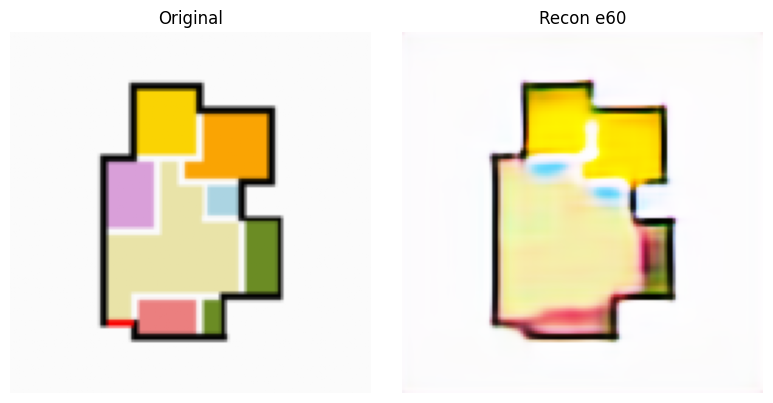

  ✓ saved best checkpoint (recon=0.0944)
VQ-VAE training complete.


In [9]:
import lpips as lpips_lib
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

perceptual = lpips_lib.LPIPS(net='vgg').to(cfg.device).eval()

opt_vq   = optim.AdamW(vqvae.parameters(),   lr=2e-4, weight_decay=1e-4, betas=(0.5, 0.9))
opt_disc = optim.AdamW(disc.parameters(),    lr=2e-4, weight_decay=1e-4, betas=(0.5, 0.9))

# cosine annealing with warm restarts — better than plain cosine for 60 epochs
sched_vq   = CosineAnnealingWarmRestarts(opt_vq,   T_0=20, T_mult=2)
sched_disc = CosineAnnealingWarmRestarts(opt_disc, T_0=20, T_mult=2)
scaler     = torch.amp.GradScaler('cuda')

# warmup: linearly ramp LR from 0 to 2e-4 over first 5 epochs
warmup_epochs = 5
warmup_factor = 0.0

# ── track history for plotting later ───────────────────────────
history = {'recon': [], 'commit': [], 'perc': [], 'adv_g': [], 'adv_d': [], 'total': []}
best_recon = float('inf')
adv_start_epoch = 10   # delay adversarial loss — let the autoencoder stabilise first

print('── Training VQ-VAE ──────────────────────────────────────────')
for epoch in range(cfg.vq_epochs):

    # linear warmup
    if epoch < warmup_epochs:
        warmup_factor = (epoch + 1) / warmup_epochs
        for g in opt_vq.param_groups:
            g['lr'] = 2e-4 * warmup_factor
        for g in opt_disc.param_groups:
            g['lr'] = 2e-4 * warmup_factor

    vqvae.train(); disc.train()
    sum_recon = sum_commit = sum_perc = sum_adv_g = sum_adv_d = 0.0
    use_adv   = (epoch >= adv_start_epoch)

    for step, (imgs, _) in enumerate(loader):
        imgs = imgs.to(cfg.device).float() # Explicitly cast to float32

        # ── generator / VQ-VAE update ──────────────
        with torch.amp.autocast('cuda'):
            recon, commit, _ = vqvae(imgs)
            l_recon = F.l1_loss(recon, imgs)
            l_perc  = perceptual(recon, imgs).mean()
            l_adv_g = generator_hinge_loss(disc, recon) if use_adv else torch.tensor(0.)
            loss_g  = (cfg.lambda_recon  * l_recon
                     + cfg.lambda_commit * commit
                     + cfg.lambda_perc   * l_perc
                     + cfg.lambda_adv    * l_adv_g)

        scaler.scale(loss_g / cfg.grad_accum).backward()
        if (step + 1) % cfg.grad_accum == 0:
            scaler.unscale_(opt_vq)
            nn.utils.clip_grad_norm_(vqvae.parameters(), 1.0)
            scaler.step(opt_vq); scaler.update(); opt_vq.zero_grad()

        # ── discriminator update ─────────────
        if use_adv:
            with torch.amp.autocast('cuda'):
                l_adv_d = discriminator_hinge_loss(disc, imgs, recon)
            scaler.scale(l_adv_d / cfg.grad_accum).backward()
            if (step + 1) % cfg.grad_accum == 0:
                scaler.unscale_(opt_disc)
                nn.utils.clip_grad_norm_(disc.parameters(), 1.0)
                scaler.step(opt_disc); scaler.update(); opt_disc.zero_grad()
            sum_adv_d += l_adv_d.item()

        sum_recon  += l_recon.item()
        sum_commit += commit.item()
        sum_perc   += l_perc.item()
        sum_adv_g  += l_adv_g.item() if use_adv else 0.

    if epoch >= warmup_epochs:
        sched_vq.step(); sched_disc.step()

    # ── log every 5 epochs ────────────────────────────────────────────────
    n = len(loader)
    avg_recon = sum_recon / n
    history['recon'].append(avg_recon)
    history['commit'].append(sum_commit / n)
    history['perc'].append(sum_perc / n)
    history['adv_g'].append(sum_adv_g / n)
    history['adv_d'].append(sum_adv_d / n)
    history['total'].append((sum_recon + sum_commit + sum_perc + sum_adv_g) / n)

    if (epoch + 1) % 5 != 0:
        continue

    # codebook utilisation check
    vqvae.eval()
    used = set()
    with torch.no_grad():
        for imgs_val, _ in loader:
            _, _, idx = vqvae(imgs_val.to(cfg.device).float()) # Explicitly cast to float32
            used.update(idx.cpu().numpy().flatten().tolist())
            if len(used) > cfg.codebook_size // 2:
                break
    util = len(used) / cfg.codebook_size

    print(f'epoch {epoch+1:3d}/{cfg.vq_epochs} '
          f'| recon {avg_recon:.4f} '
          f'| commit {sum_commit/n:.4f} '
          f'| lpips {sum_perc/n:.4f} '
          f'| adv_g {sum_adv_g/n:.4f} '
          f'| adv_d {sum_adv_d/n:.4f} '
          f'| codebook util {util*100:.1f}%')

    # visual check
    with torch.no_grad():
        sample = imgs[:1]
        rec, _, _ = vqvae(sample)

    gt_np  = np.clip(sample[0].cpu().permute(1,2,0).numpy() * .5 + .5, 0, 1)
    rec_np = np.clip(rec[0].cpu().permute(1,2,0).numpy()    * .5 + .5, 0, 1)
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(gt_np);  axs[0].set_title('Original');         axs[0].axis('off')
    axs[1].imshow(rec_np); axs[1].set_title(f'Recon e{epoch+1}'); axs[1].axis('off')
    plt.tight_layout(); plt.show()

    if avg_recon < best_recon:
        best_recon = avg_recon
        torch.save({
            'vqvae': vqvae.state_dict(),
            'disc':  disc.state_dict(),
            'epoch': epoch + 1,
        }, f'{cfg.ckpt_dir}/vqvae_best.pt')
        print(f'  ✓ saved best checkpoint (recon={best_recon:.4f})')

    vqvae.train()

print('VQ-VAE training complete.')

In [ ]:
# ── 8. Load LLM (Llama-3.2-1B) with LoRA ────────────────────────────
login(token="your_hf_token")   # Hugging Face token provided by user

tokenizer = AutoTokenizer.from_pretrained(cfg.model_id)
tokenizer.pad_token = tokenizer.eos_token

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

base_llm = AutoModelForCausalLM.from_pretrained(
    cfg.model_id,
    quantization_config=bnb_cfg,
    device_map='auto',
)

lora_config = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    target_modules=['q_proj','k_proj','v_proj','o_proj',
                   'gate_proj','up_proj','down_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
)

base_llm = prepare_model_for_kbit_training(base_llm)
llm = get_peft_model(base_llm, lora_config)
llm.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


In [11]:
class CausalTransformer(nn.Module):
    """
    Auto-regressive transformer that predicts the next VQ token.
    Text conditioning is injected as cross-attention memory.
    Supports classifier-free guidance via null_emb dropout.

    Architecture:
      - Token embedding (codebook_size+1 including SOS)
      - Sinusoidal positional encoding (more robust than learned for seq extrapolation)
      - 12-layer TransformerDecoder (self-attn + cross-attn to text)
      - Linear head → logits over codebook
    """

    def __init__(self):
        super().__init__()
        self.D = cfg.d_model      # 768
        SOS = cfg.codebook_size

        # ── text conditioning ───────────
        # LLM hidden dim for Llama-3.2-1B is 2048
        self.text_proj = nn.Sequential(
            nn.Linear(2048, self.D * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(self.D * 2, self.D),
            nn.LayerNorm(self.D),
        )
        self.null_emb = nn.Parameter(torch.zeros(1, 1, self.D))
        nn.init.normal_(self.null_emb, std=0.02)

        # ── token & position embeddings ───────────
        self.tok_emb = nn.Embedding(SOS + 1, self.D)  # +1 for SOS token
        self.register_buffer(
            'pos_ids', torch.arange(cfg.seq_len + 1).unsqueeze(0)
        )
        self.pos_emb = nn.Embedding(cfg.seq_len + 1, self.D)

        # ── transformer decoder ─────────────
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=self.D, nhead=cfg.nhead,
            dim_feedforward=self.D * 4,
            dropout=0.1,
            batch_first=True,
            norm_first=True,          # pre-norm — more stable
            activation='gelu',
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=cfg.n_layers)
        self.ln_final    = nn.LayerNorm(self.D)
        self.head        = nn.Linear(self.D, cfg.codebook_size, bias=False)

        # tie token embedding weights to output head (reduces params, better generalisation)
        # Fix: Delete the existing Parameter and register a new one from the sliced tensor
        del self.head.weight # Remove the original Parameter object
        self.head.register_parameter('weight', nn.Parameter(self.tok_emb.weight[:cfg.codebook_size]))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def get_text_features(self, text_feats, drop_text=False):
        B = text_feats.shape[0]
        ctx = self.text_proj(text_feats.float())       # (B, T_txt, D)
        if drop_text:
            ctx = self.null_emb.expand(B, ctx.shape[1], self.D)
        return ctx

    def forward(self, text_feats, tok_seq, drop_text=False):
        """
        text_feats: (B, T_txt, 2048)  — last hidden states from LLM
        tok_seq:    (B, S)            — ground-truth token indices (no SOS)
        Returns logits: (B, S+1, codebook_size)  — predicts tok at each position
        """
        B, S = tok_seq.shape
        D_model = self.D # Renamed to avoid confusion with local D

        # prepend SOS
        sos  = tok_seq.new_full((B, 1), cfg.codebook_size)
        toks = torch.cat([sos, tok_seq], dim=1)          # (B, S+1)

        # embeddings
        x = self.tok_emb(toks) + self.pos_emb(self.pos_ids[:, :toks.shape[1]])

        # causal mask
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            toks.shape[1], device=toks.device
        )

        # text conditioning (with optional CFG dropout)
        ctx = self.get_text_features(text_feats, drop_text=drop_text)

        out    = self.transformer(x, ctx, tgt_mask=causal_mask)
        logits = self.head(self.ln_final(out))            # (B, S+1, codebook_size)
        return logits


trans = CausalTransformer().to(cfg.device)
print(f'Transformer parameters: {sum(p.numel() for p in trans.parameters())/1e6:.1f}M')

# sanity check
with torch.no_grad():
    dummy_txt  = torch.randn(2, 10, 2048, device=cfg.device)
    dummy_toks = torch.randint(0, cfg.codebook_size, (2, cfg.seq_len), device=cfg.device)
    logits_out = trans(dummy_txt, dummy_toks)
    print(f'  logits shape: {tuple(logits_out.shape)} '
          f'(expected (2, {cfg.seq_len+1}, {cfg.codebook_size}))')


Transformer parameters: 121.1M
  logits shape: (2, 257, 2048) (expected (2, 257, 2048))


In [12]:
# ── 10. Train Causal Transformer + LoRA ─────────────────────────────────────
from torch.optim.lr_scheduler import OneCycleLR

# load best vqvae checkpoint
ckpt = torch.load(f'{cfg.ckpt_dir}/vqvae_best.pt', map_location=cfg.device)
vqvae.load_state_dict(ckpt['vqvae'])
vqvae.eval()
print(f'Loaded VQ-VAE checkpoint from epoch {ckpt["epoch"]}')

params_trans = list(trans.parameters()) + [p for p in llm.parameters() if p.requires_grad]
total_steps  = cfg.trans_epochs * len(loader) // cfg.grad_accum

opt_tr = optim.AdamW(params_trans, lr=1e-4, weight_decay=1e-4, betas=(0.9, 0.95))

# OneCycleLR: warmup then cosine decay — great for transformers
sched_tr = OneCycleLR(
    opt_tr, max_lr=1e-4,
    total_steps=total_steps,
    pct_start=0.05,          # 5% warmup
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=100,
)

scaler_tr = torch.amp.GradScaler('cuda')
history_tr = {'ce': [], 'lr': []}

print('── Training Transformer ─────────────────────────────────────────────────')
for epoch in range(cfg.trans_epochs):
    trans.train(); llm.train()
    sum_ce = 0.0
    last_lr = 0.0

    for step, (imgs, texts) in enumerate(loader):
        imgs = imgs.to(cfg.device)

        with torch.amp.autocast('cuda'):
            # 1. get text features from LLM
            toks_out = tokenizer(
                list(texts),
                return_tensors='pt', padding=True,
                truncation=True, max_length=64
            ).to(cfg.device)
            text_feats = llm(**toks_out, output_hidden_states=True).hidden_states[-1]
            # text_feats: (B, T_txt, 2048)

            # 2. get VQ token indices from frozen VQ-VAE
            with torch.no_grad():
                _, _, indices = vqvae.encode(imgs)   # (B, seq_len)

            # 3. classifier-free guidance dropout
            drop = (torch.rand(1).item() < cfg.cfg_prob)

            # 4. forward through transformer
            # logits[:, :-1] corresponds to predicting each token from position 1..S
            logits = trans(text_feats, indices, drop_text=drop)  # (B, S+1, K)

            # shift: position i predicts index[i]
            ce_loss = F.cross_entropy(
                logits[:, :-1].reshape(-1, cfg.codebook_size),
                indices.reshape(-1),
            )

        scaler_tr.scale(ce_loss / cfg.grad_accum).backward()

        if (step + 1) % cfg.grad_accum == 0:
            scaler_tr.unscale_(opt_tr)
            nn.utils.clip_grad_norm_(params_trans, 1.0)
            scaler_tr.step(opt_tr)
            scaler_tr.update()
            opt_tr.zero_grad(set_to_none=True)
            if len(sched_tr.get_last_lr()):
                sched_tr.step()
                last_lr = sched_tr.get_last_lr()[0]

        sum_ce += ce_loss.item()

    avg_ce = sum_ce / len(loader)
    history_tr['ce'].append(avg_ce)
    history_tr['lr'].append(last_lr)

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1:3d}/{cfg.trans_epochs} '
              f'| ce {avg_ce:.4f} '
              f'| lr {last_lr:.2e}')
        torch.save({
            'trans': trans.state_dict(),
            'llm':   llm.state_dict(),
            'epoch': epoch + 1,
        }, f'{cfg.ckpt_dir}/trans_ep{epoch+1}.pt')

print('Transformer training complete.')


Loaded VQ-VAE checkpoint from epoch 60
── Training Transformer ─────────────────────────────────────────────────


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


epoch   5/80 | ce 4.3056 | lr 1.00e-04
epoch  10/80 | ce 3.2110 | lr 9.86e-05
epoch  15/80 | ce 2.8851 | lr 9.53e-05
epoch  20/80 | ce 2.6643 | lr 9.03e-05
epoch  25/80 | ce 2.5396 | lr 8.36e-05
epoch  30/80 | ce 2.4305 | lr 7.57e-05
epoch  35/80 | ce 2.3329 | lr 6.67e-05
epoch  40/80 | ce 2.2416 | lr 5.71e-05
epoch  45/80 | ce 2.1950 | lr 4.72e-05
epoch  50/80 | ce 2.1573 | lr 3.74e-05
epoch  55/80 | ce 2.1465 | lr 2.81e-05
epoch  60/80 | ce 2.0755 | lr 1.97e-05
epoch  65/80 | ce 2.0783 | lr 1.25e-05
epoch  70/80 | ce 2.0289 | lr 6.71e-06
epoch  75/80 | ce 2.0324 | lr 2.64e-06
epoch  80/80 | ce 2.0723 | lr 4.34e-07
Transformer training complete.


In [ ]:
# ── 11. Inference with Classifier-Free Guidance ─────────────────────────────

@torch.no_grad()
def generate(prompt, guidance=4.0, temp=1.0, top_k=256, top_p=0.95):
    """
    Auto-regressively sample a floor plan image from a text prompt.
    guidance: CFG scale (1.0 = no guidance, 4-7 = good range)
    temp:     softmax temperature (lower = less random, higher = more diverse)
    top_k:    keep only top-k logits before sampling
    top_p:    nucleus threshold
    """
    trans.eval(); vqvae.eval(); llm.eval()

    # encode text
    toks_out = tokenizer(
        [prompt], return_tensors='pt', padding=True,
        truncation=True, max_length=64
    ).to(cfg.device)
    text_feats = llm(**toks_out, output_hidden_states=True).hidden_states[-1]

    # auto-regressive generation
    generated = []   # list of sampled token ids
    seq       = torch.full((1, 1), cfg.codebook_size,
                           dtype=torch.long, device=cfg.device)  # SOS

    for pos in range(cfg.seq_len):
        # current tokens fed to transformer (strip SOS from past output)
        cur_toks = torch.tensor([generated], dtype=torch.long,
                                device=cfg.device) if generated else                    torch.zeros(1, 0, dtype=torch.long, device=cfg.device)

        # we need at least one token; use a dummy zero before first real token
        if cur_toks.shape[1] == 0:
            cur_toks = torch.zeros(1, 1, dtype=torch.long, device=cfg.device)
            # get logits at position 0 (after SOS)
            logits_cond   = trans(text_feats, cur_toks)[:, 0]
            logits_uncond = trans(text_feats, cur_toks, drop_text=True)[:, 0]
        else:
            # build full seq so far and get last position's logits
            logits_cond   = trans(text_feats, cur_toks)[:, -1]
            logits_uncond = trans(text_feats, cur_toks, drop_text=True)[:, -1]

        # classifier-free guidance
        logits = logits_uncond + guidance * (logits_cond - logits_uncond)
        logits = logits / temp

        # top-k filtering
        if top_k > 0:
            top_vals, _ = torch.topk(logits, top_k)
            logits[logits < top_vals[:, -1:]] = float('-inf')

        # nucleus (top-p) filtering
        probs       = F.softmax(logits, dim=-1)
        sorted_p, sorted_idx = torch.sort(probs, descending=True)
        cum_p = sorted_p.cumsum(dim=-1)
        remove = (cum_p - sorted_p) > top_p
        sorted_p[remove] = 0.
        sorted_p = sorted_p / sorted_p.sum(dim=-1, keepdim=True)
        # scatter back
        final_p = torch.zeros_like(probs).scatter_(1, sorted_idx, sorted_p)
        next_tok = torch.multinomial(final_p, 1).item()
        generated.append(next_tok)

    # decode tokens → image
    token_tensor = torch.tensor(generated, device=cfg.device).unsqueeze(0)  # (1, seq_len)
    H = W = cfg.img_size // 8   # 16
    z_q = vqvae.codebook_module.codebook[token_tensor]   # (1, seq_len, D)
    z_q = rearrange(z_q, '1 (h w) d -> 1 d h w', h=H, w=W)
    img_tensor = vqvae.decode(z_q).squeeze(0)
    img_np = np.clip(img_tensor.permute(1,2,0).cpu().numpy() * .5 + .5, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    plt.title(prompt[:70], fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return img_np




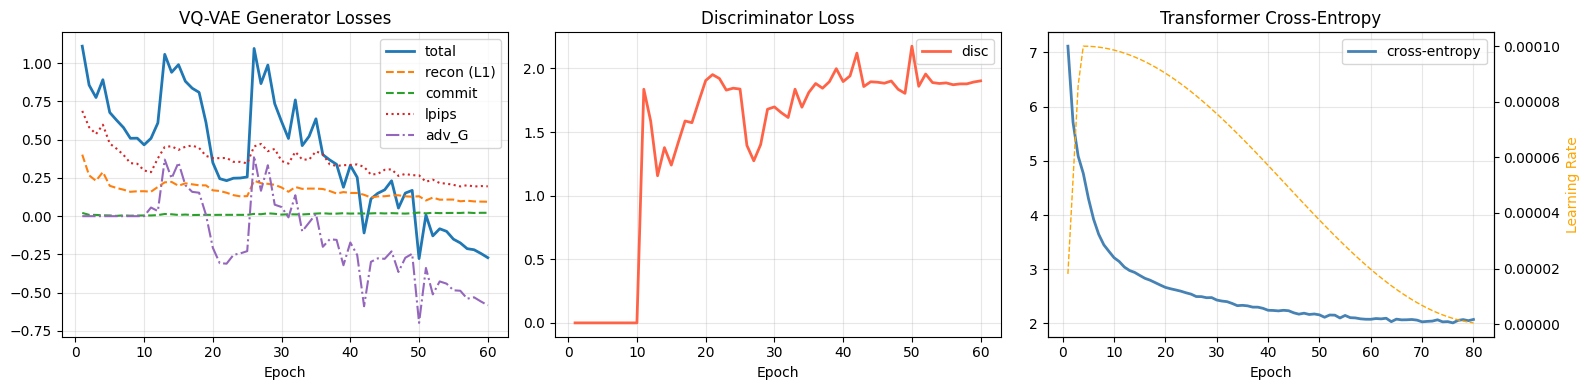

Curves saved to /content/drive/MyDrive/DALEEtrain/floorplan_ckpts_v3


In [14]:
# ── 12. Plot Training Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# VQ-VAE losses
epochs_vq = list(range(1, len(history['total']) + 1))
axes[0].plot(epochs_vq, history['total'],  label='total',       lw=2)
axes[0].plot(epochs_vq, history['recon'],  label='recon (L1)',  lw=1.5, ls='--')
axes[0].plot(epochs_vq, history['commit'], label='commit',      lw=1.5, ls='--')
axes[0].plot(epochs_vq, history['perc'],   label='lpips',       lw=1.5, ls=':')
axes[0].plot(epochs_vq, history['adv_g'],  label='adv_G',       lw=1.5, ls='-.')
axes[0].set_title('VQ-VAE Generator Losses'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_vq, history['adv_d'], label='disc', lw=2, color='tomato')
axes[1].set_title('Discriminator Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Transformer CE loss
epochs_tr = list(range(1, len(history_tr['ce']) + 1))
ax2 = axes[2]
ax2.plot(epochs_tr, history_tr['ce'], label='cross-entropy', lw=2, color='steelblue')
ax2.set_title('Transformer Cross-Entropy'); ax2.set_xlabel('Epoch')
ax2_r = ax2.twinx()
ax2_r.plot(epochs_tr, history_tr['lr'], label='LR', lw=1, color='orange', ls='--')
ax2_r.set_ylabel('Learning Rate', color='orange')
ax2.legend(loc='upper right'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.ckpt_dir}/training_curves.png', dpi=150)
plt.show()
print('Curves saved to', cfg.ckpt_dir)


In [15]:
# ── 13. FID Evaluation ──────────────────────────────────────────────────────
from torchmetrics.image.fid import FrechetInceptionDistance

def compute_fid(n_samples=100, guidance=4.0, temp=1.0):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(cfg.device)
    fid.reset()


    real_count = 0
    for imgs, _ in loader:
        real = (imgs * 0.5 + 0.5).clamp(0, 1)  # un-normalise to [0,1]
        fid.update(real.to(cfg.device), real=True)
        real_count += imgs.shape[0]
        if real_count >= n_samples:
            break


    gen_count = 0
    for img_path, txt_path in dataset.pairs[:n_samples]:
        caption = open(txt_path).read().strip()
        img_np  = generate(caption, guidance=guidance, temp=temp)
        fake    = torch.tensor(img_np, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
        fid.update(fake.to(cfg.device), real=False)
        gen_count += 1
        if gen_count >= n_samples:
            break

    score = fid.compute().item()
    print(f'FID ({n_samples} samples, guidance={guidance}): {score:.2f}')
    return score


# uncomment to run evaluation:
# fid_score = compute_fid(n_samples=100, guidance=4.0)


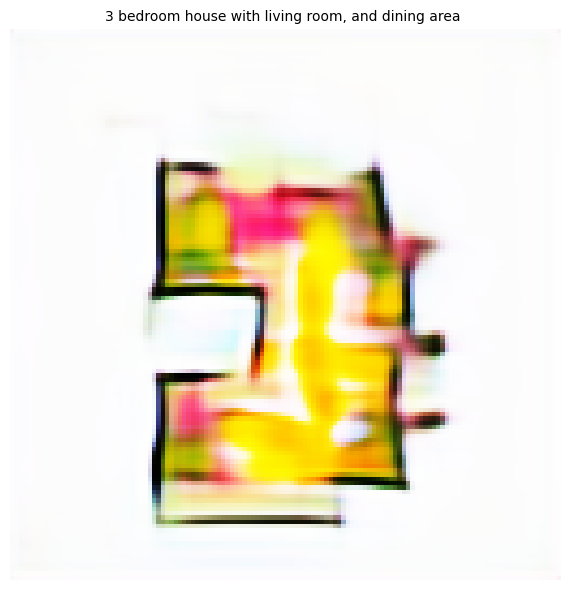

array([[[0.9797059 , 0.9528328 , 0.96777093],
        [0.9876315 , 0.9821977 , 0.988561  ],
        [0.98833567, 0.9844072 , 0.9891994 ],
        ...,
        [0.99234676, 0.98676777, 0.9887798 ],
        [0.9935095 , 0.9808347 , 0.9876793 ],
        [0.9843416 , 0.95878077, 0.9646384 ]],

       [[0.98704493, 0.9758324 , 0.98495805],
        [0.9825826 , 0.98191553, 0.9921658 ],
        [0.973873  , 0.9791269 , 0.98697245],
        ...,
        [0.9877937 , 0.986379  , 0.98565423],
        [0.99430317, 0.9862063 , 0.9896335 ],
        [0.99267477, 0.98233485, 0.9843404 ]],

       [[0.9869254 , 0.979622  , 0.9833185 ],
        [0.9758986 , 0.9790188 , 0.98581874],
        [0.96812195, 0.9746856 , 0.96952224],
        ...,
        [0.98530865, 0.9841424 , 0.971478  ],
        [0.993889  , 0.9854212 , 0.9853443 ],
        [0.9949771 , 0.9869563 , 0.9861414 ]],

       ...,

       [[0.989648  , 0.9875113 , 0.9885335 ],
        [0.98096836, 0.9894842 , 0.98631597],
        [0.97537607, 0

In [25]:
generate('3 bedroom house with living room, and dining area ', guidance=4.5)


In [ ]:
pip install nbformat

In [2]:
import nbformat

nb = nbformat.read("floorplan_vqvae_transformer_final.ipynb", as_version=4)

# Remove problematic widget metadata
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, "fixed_notebook.ipynb")